In [ ]:
!pip install pandas lightgbm shap scikit-learn matplotlib

In [ ]:
import pandas as pd

df = pd.read_csv('./distributed_system_architecture_stress_dataset.csv')  # แทนที่ 'your_data.csv' ด้วยชื่อไฟล์ของคุณ

# สมมติว่า df คือตารางของคุณ และ 'status' คือชื่อคอลัมน์
filtered_df = df[df['root_cause'].isin(['none', 'network_partition'])]
print(filtered_df)
filtered_df.drop(columns=['root_cause'], inplace=True)  # ลบคอลัมน์ 'root_cause' ออกจาก DataFrame ที่ถูกกรอง
# แสดงข้อมูลที่ถูกกรอง
filtered_df.to_csv('filtered_data.csv', index=False)  # บันทึกข้อมูลที่ถูกกรองลงไฟล์ CSV ใหม่

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008755 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2678
[LightGBM] [Info] Number of data points in the train set: 158964, number of used features: 18
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


<Figure size 1000x800 with 0 Axes>

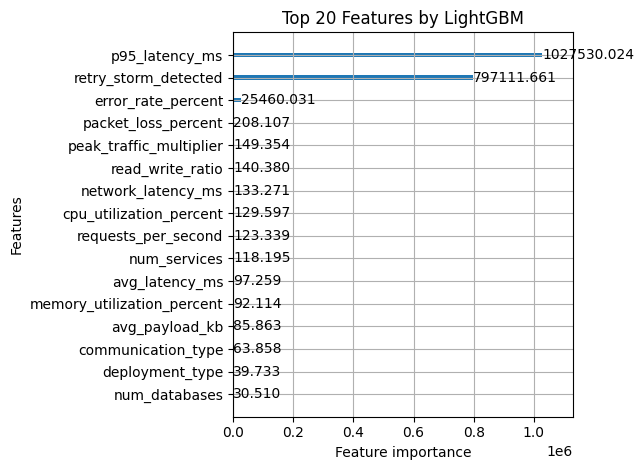

กำลังสร้างกราฟ SHAP Summary Plot...


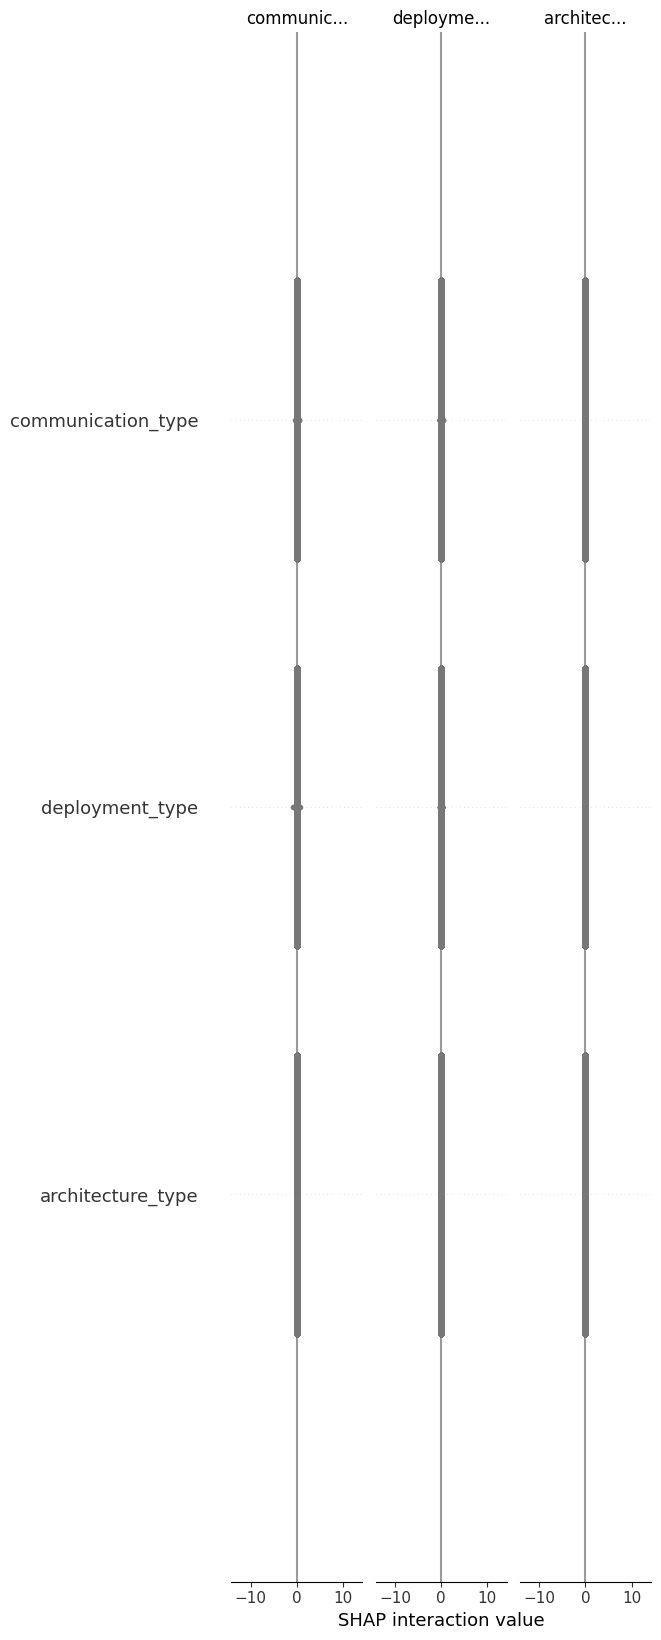

In [7]:
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ==========================================
# 1. โหลดข้อมูลของคุณ
# ==========================================
# เปลี่ยน 'your_data.csv' เป็นชื่อไฟล์ของคุณ
df = pd.read_csv('./filtered_data.csv')

# ระบุชื่อคอลัมน์ที่เป็นเป้าหมาย (Target) หรือ Error Code ของคุณ
target_column = 'system_state' 

# ==========================================
# 2. แยก Features (X) และ Target (y)
# ==========================================
X = df.drop(columns=[target_column])
y = df[target_column]

# ==========================================
# 3. จัดการข้อมูลประเภทข้อความ (Minimal Pre-processing)
# ==========================================
# LightGBM สามารถจัดการ Categorical Data ได้เอง แต่ต้องแปลงชนิดข้อมูลใน Pandas ให้เป็น 'category' ก่อน
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].astype('category')

# ==========================================
# 4. แบ่งข้อมูลสำหรับ Train และ Test
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 5. สร้างและเทรนโมเดล LightGBM
# ==========================================
# ใช้ class_weight='balanced' เพื่อให้โมเดลให้ความสำคัญกับ Error ที่อาจจะเกิดน้อยกว่าข้อมูลปกติ
model = lgb.LGBMClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# ==========================================
# 6. พล็อตกราฟ Feature Importance แบบพื้นฐาน (เร็วสุด)
# ==========================================
plt.figure(figsize=(10, 8))
lgb.plot_importance(model, max_num_features=20, importance_type='gain', title='Top 20 Features by LightGBM')
plt.tight_layout()
plt.show()

# ==========================================
# 7. วิเคราะห์เชิงลึกด้วย SHAP Values (แม่นยำและอธิบายสาเหตุได้)
# ==========================================
# สร้าง SHAP Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# พล็อตกราฟสรุป (Summary Plot)
print("กำลังสร้างกราฟ SHAP Summary Plot...")
# หมายเหตุ: หาก y (Error Code) มีหลายคลาส (Multiclass) shap_values จะเป็นลิสต์
# ให้ระบุคลาสที่ต้องการดู เช่น shap_values[1] แต่ถ้าเป็น Binary (ปกติ กับ Error) ใช้ shap_values ได้เลย
shap.summary_plot(shap_values, X_test, max_display=20)

# RCA

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
import matplotlib.pyplot as plt

# ==========================================
# 1. สร้างข้อมูลตัวอย่างแบบ Attributes (Mock Data)
# ==========================================
np.random.seed(42)
n_samples = 1500

# จำลองวันที่ผลิต (ช่วง 1 เดือน)
dates = pd.date_range(start='2026-03-01', periods=30).to_series().dt.strftime('%Y-%m-%d').to_list()

# จำลอง Attributes ของสายการผลิต
data = {
    'Production_Date': np.random.choice(dates, n_samples),
    'Process_Line': np.random.choice(['Line_A', 'Line_B', 'Line_C', 'Line_D'], n_samples),
    'Product_Spec': np.random.choice(['Spec_Std', 'Spec_Premium', 'Spec_Export'], n_samples),
    'Machine_ID': np.random.choice([f'MC_{i:03d}' for i in range(1, 51)], n_samples), # มีเครื่องจักร 50 เครื่อง
    'Material_Supplier': np.random.choice(['Supplier_X', 'Supplier_Y', 'Supplier_Z'], n_samples),
    'Operator_Shift': np.random.choice(['Day_Shift', 'Night_Shift'], n_samples),
    'Total_Volume': np.random.randint(50, 10000, size=n_samples) # ปริมาณผลิตแต่ละ Lot
}
df = pd.DataFrame(data)

# --- ซ่อน Root Cause ไว้ทดสอบโมเดล ---
# สมมติว่า: ของเสียจะเยอะเป็นพิเศษ ถ้าผลิตจาก "Line_C" และใช้วัตถุดิบจาก "Supplier_Y"
base_defect_rate = np.where(
    (df['Process_Line'] == 'Line_C') & (df['Material_Supplier'] == 'Supplier_Y'),
    np.random.uniform(0.15, 0.30, size=n_samples), # Yield Loss สูง (15-30%)
    np.random.uniform(0.01, 0.05, size=n_samples)  # ปกติ (1-5%)
)

# เพิ่ม Noise: Lot ที่ผลิตน้อยๆ (< 500) มักจะมี % ของเสียแกว่งและสูงผิดปกติ
low_vol_mask = df['Total_Volume'] < 500
base_defect_rate[low_vol_mask] = np.random.uniform(0.4, 0.8, size=low_vol_mask.sum())

df['Defect_Qty'] = (df['Total_Volume'] * base_defect_rate).astype(int)
df['Yield_Loss_Pct'] = (df['Defect_Qty'] / df['Total_Volume']) * 100

print(f"ข้อมูลดิบตั้งต้น: {len(df)} แถว")
print(df.head(3))


# ==========================================
# 2. ระบบกรองข้อมูลอัตโนมัติ (Automated Filter)
# ==========================================
MIN_VOLUME = 500
# ตัด Lot ที่ผลิตน้อยกว่า 500 ทิ้งไป เพื่อไม่ให้นำมาคิดหาสาเหตุ
df_filtered = df[df['Total_Volume'] >= MIN_VOLUME].copy()
print(f"\nข้อมูลหลังกรอง (Volume >= 500): {len(df_filtered)} แถว")


# ==========================================
# 3. เตรียมข้อมูลสำหรับ ML (Data Preprocessing)
# ==========================================
# เลือกคอลัมน์ Attributes ที่จะนำมาวิเคราะห์ (ไม่เอา Date มาวิเคราะห์โดยตรง ยกเว้นจะแปลงเป็น Day of Week)
categorical_features = ['Process_Line', 'Product_Spec', 'Machine_ID', 'Material_Supplier', 'Operator_Shift']

# *** แปลงข้อความให้เป็นคอลัมน์ (One-Hot Encoding) ***
# ขั้นตอนนี้แหละที่จะขยายคอลัมน์ออกไปเป็นจำนวนมาก (เช่นจาก 5 กลายเป็น 60+ คอลัมน์)
X = pd.get_dummies(df_filtered[categorical_features])
y = df_filtered['Yield_Loss_Pct']

# สมมติว่ามีเซนเซอร์พารามิเตอร์อื่นๆ ด้วย เพื่อจำลองให้ครบ 400 คอลัมน์ตามโจทย์
for i in range(X.shape[1], 400):
    X[f'Sensor_Dummy_{i}'] = np.random.rand(len(X))

print(f"จำนวน Features หลังทำ Encoding และรวมเซนเซอร์: {X.shape[1]} คอลัมน์")


# ==========================================
# 4. Feature Selection & Node Creation
# ==========================================
print("\nกำลังคัดเลือก Features ที่ส่งผลให้ Yield ตกมากที่สุด...")
rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X, y)

# เลือก 5 คอลัมน์ที่มีผลที่สุด
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_5_features = importances.nlargest(5).index.tolist()
print(f"Top 5 Features: {top_5_features}")

# สร้าง Node ด้วย Decision Tree
X_top = X[top_5_features]
dtree = DecisionTreeRegressor(max_depth=3, random_state=42)
dtree.fit(X_top, y)

# ==========================================
# 5. สรุปผลลัพธ์ (Rule Extraction)
# ==========================================
print("\n--- Root Cause Report (วิเคราะห์จาก Attributes) ---")
tree_rules = export_text(dtree, feature_names=top_5_features)
print(tree_rules)

# พล็อตกราฟต้นไม้
plt.figure(figsize=(12, 6))
plot_tree(dtree, feature_names=top_5_features, filled=True, rounded=True, precision=2)
plt.title("Root Cause Analysis (Attributes -> Yield Loss %)")
plt.show()